# FlowTrace — EDA on AMLworld HI-Small

**Goal:** understand the dataset completely before building any model.

- What's in it (rows, columns, types)
- How much laundering is there (class balance)
- Time span (for temporal split planning)
- Distributions of amounts, currencies, formats
- Account and bank structure
- Data quality issues
- Pattern file content (which laundering typologies, how many)

In [2]:
# Standard imports and plotting config
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

# Project root (notebook is in notebooks/, project root is one level up)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print("Project root:", PROJECT_ROOT)
print("Data dir:    ", DATA_RAW)
print("Figures dir: ", FIG_DIR)

Project root: c:\Users\Priyam Srivastava\code\flowtrace
Data dir:     c:\Users\Priyam Srivastava\code\flowtrace\data\raw
Figures dir:  c:\Users\Priyam Srivastava\code\flowtrace\reports\figures


In [3]:
# Load HI-Small using our canonical loader
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from flowtrace.data.schema import load_transactions

df = load_transactions(DATA_RAW / "HI-Small_Trans.csv")
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.estimated_size('mb'):,.0f} MB in RAM")
print()
print("Schema:")
for name, dtype in df.schema.items():
    print(f"  {name:<22s} {dtype}")

Loaded 5,078,345 rows × 11 columns
Memory: 428 MB in RAM

Schema:
  ts                     Datetime(time_unit='us', time_zone=None)
  from_bank              Int64
  from_account           String
  to_bank                Int64
  to_account             String
  amount_received        Float64
  currency_received      String
  amount_paid            Float64
  currency_paid          String
  payment_format         String
  is_laundering          Int64


## 3. Class balance — how rare is laundering?

The headline number. If 1 in 10 transactions were fraud, this would be a 10-minute project. In reality it's extreme imbalance, and that shapes every downstream choice (metrics, loss function, thresholds).

In [4]:
# Count labels
label_counts = df.group_by("is_laundering").agg(pl.len().alias("count")).sort("is_laundering")
total = df.height

print("Class distribution:")
for row in label_counts.iter_rows(named=True):
    label = "Laundering" if row["is_laundering"] == 1 else "Legitimate"
    pct = 100 * row["count"] / total
    print(f"  {label:<12s}  {row['count']:>10,}  ({pct:.4f}%)")

print(f"\nTotal:         {total:>10,}")

n_pos = label_counts.filter(pl.col("is_laundering") == 1)["count"].item()
n_neg = label_counts.filter(pl.col("is_laundering") == 0)["count"].item()
ratio = n_neg / n_pos
print(f"\nImbalance ratio: 1 laundering : {ratio:,.0f} legitimate")

Class distribution:
  Legitimate     5,073,168  (99.8981%)
  Laundering         5,177  (0.1019%)

Total:          5,078,345

Imbalance ratio: 1 laundering : 980 legitimate


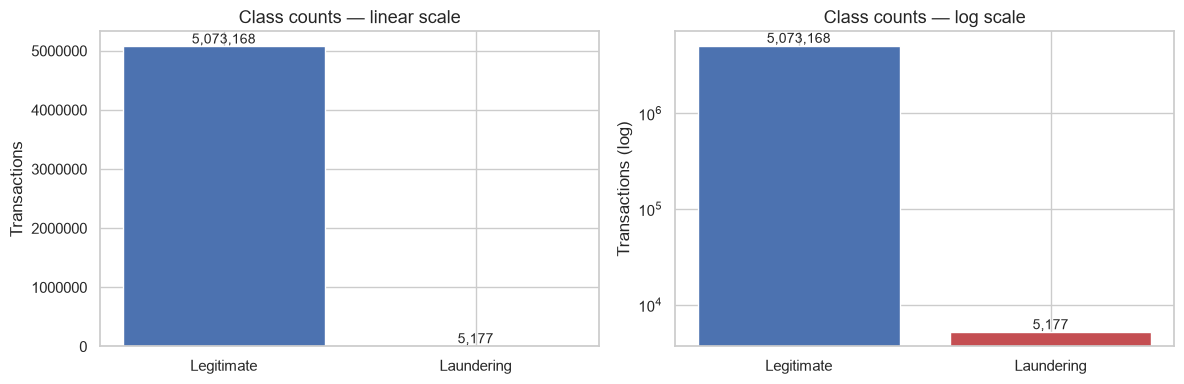

Saved: c:\Users\Priyam Srivastava\code\flowtrace\reports\figures\01_class_balance.png


In [5]:
# Bar chart (not pie — pie charts hide imbalance)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = label_counts.to_pandas().set_index("is_laundering")["count"]
colors = ["#4c72b0", "#c44e52"]

# Left: linear scale (shows how invisible the minority class is)
ax1.bar(["Legitimate", "Laundering"], counts.values, color=colors)
ax1.set_title("Class counts — linear scale")
ax1.set_ylabel("Transactions")
ax1.ticklabel_format(axis="y", style="plain")
for i, v in enumerate(counts.values):
    ax1.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

# Right: log scale (shows actual magnitudes)
ax2.bar(["Legitimate", "Laundering"], counts.values, color=colors)
ax2.set_title("Class counts — log scale")
ax2.set_ylabel("Transactions (log)")
ax2.set_yscale("log")
for i, v in enumerate(counts.values):
    ax2.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_balance.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '01_class_balance.png'}")

## 4. Time span — temporal structure

For a temporal split we need to know: when does the data start and end, is it continuous, are there daily/hourly patterns, and does laundering rate drift over time?

The split cutoffs we choose here get saved to `configs/split.yaml` and every downstream module respects them.

In [7]:
# Time span
t_min = df["ts"].min()
t_max = df["ts"].max()
span = t_max - t_min

print(f"First transaction: {t_min}")
print(f"Last transaction:  {t_max}")
print(f"Span:              {span}")
print(f"Days:              {span.days}")

# Transactions per day — sort by ts first (polars requirement)
daily = (
    df.sort("ts")
    .group_by_dynamic("ts", every="1d")
    .agg([
        pl.len().alias("total"),
        pl.col("is_laundering").sum().alias("laundering"),
    ])
    .with_columns(
        (pl.col("laundering") / pl.col("total")).alias("laundering_rate")
    )
)

print(f"\nUnique days in data: {daily.height}")
print(f"\nFirst 5 days:")
print(daily.head(5))
print(f"\nLast 5 days:")
print(daily.tail(5))

First transaction: 2022-09-01 00:00:00
Last transaction:  2022-09-18 16:18:00
Span:              17 days, 16:18:00
Days:              17

Unique days in data: 18

First 5 days:
shape: (5, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
└─────────────────────┴─────────┴────────────┴─────────────────┘

Last 5 days:
shape: (5, 4)
┌─────────────────────┬───────┬────────────┬─────────────────┐
│ t

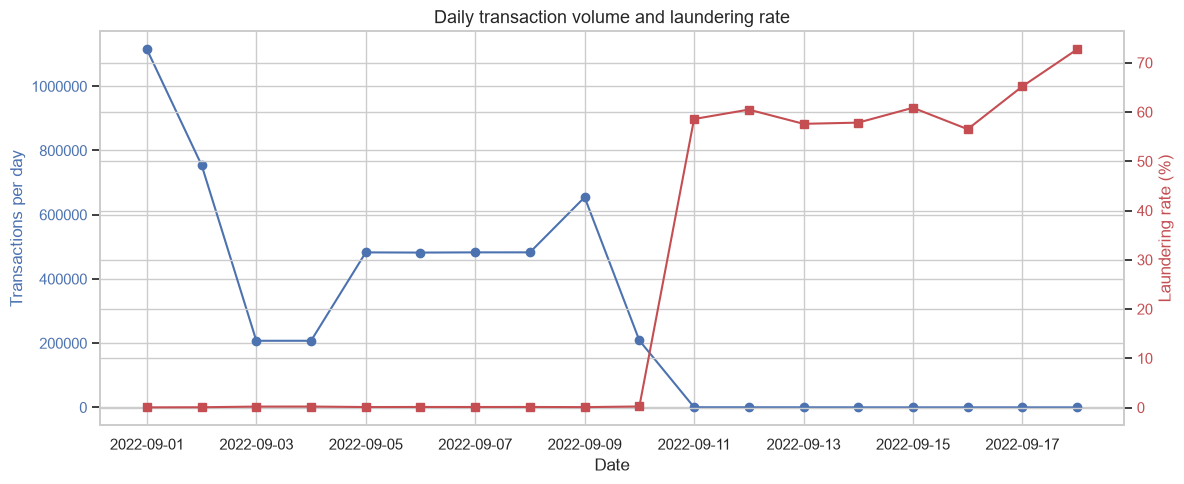

Saved: c:\Users\Priyam Srivastava\code\flowtrace\reports\figures\02_daily_volume.png


In [8]:
# Plot: transactions per day + laundering rate per day on twin axes
fig, ax1 = plt.subplots(figsize=(12, 5))

daily_pd = daily.to_pandas()

color1 = "#4c72b0"
ax1.set_xlabel("Date")
ax1.set_ylabel("Transactions per day", color=color1)
ax1.plot(daily_pd["ts"], daily_pd["total"], marker="o", color=color1, label="Total")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.ticklabel_format(axis="y", style="plain")

ax2 = ax1.twinx()
color2 = "#c44e52"
ax2.set_ylabel("Laundering rate (%)", color=color2)
ax2.plot(daily_pd["ts"], daily_pd["laundering_rate"] * 100, marker="s", color=color2, label="Laundering %")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Daily transaction volume and laundering rate")
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig(FIG_DIR / "02_daily_volume.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '02_daily_volume.png'}")

In [9]:
# Full daily table — all 18 rows
print(daily)

shape: (18, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
│ …                   ┆ …       ┆ …          ┆ …               │
│ 2022-09-14 00:00:00 ┆ 121     ┆ 70         ┆ 0.578512        │
│ 2022-09-15 00:00:00 ┆ 46      ┆ 28         ┆ 0.608696        │
│ 2022-09-16 00:00:00 ┆ 46      ┆ 26         ┆ 0.565217        │
│ 2022-09-17 00:00:00 ┆ 23      ┆ 15         ┆ 0.652174        │
│ 2022-09-

In [10]:
# Where is the volume cliff?
print("\nAll days with their volume:")
print(daily.select(["ts", "total", "laundering", "laundering_rate"]))


All days with their volume:
shape: (18, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
│ …                   ┆ …       ┆ …          ┆ …               │
│ 2022-09-14 00:00:00 ┆ 121     ┆ 70         ┆ 0.578512        │
│ 2022-09-15 00:00:00 ┆ 46      ┆ 28         ┆ 0.608696        │
│ 2022-09-16 00:00:00 ┆ 46      ┆ 26         ┆ 0.565217        │
│ 2022-09-17 00:00:00 ┆ 23      ┆ 15         ┆

In [11]:
# Force Polars to show all 18 rows (don't truncate)
with pl.Config(tbl_rows=20):
    print(daily)

shape: (18, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
│ 2022-09-06 00:00:00 ┆ 482089  ┆ 531        ┆ 0.001101        │
│ 2022-09-07 00:00:00 ┆ 482751  ┆ 497        ┆ 0.00103         │
│ 2022-09-08 00:00:00 ┆ 482773  ┆ 539        ┆ 0.001116        │
│ 2022-09-09 00:00:00 ┆ 654467  ┆ 514        ┆ 0.000785        │
│ 2022-09-10 00:00:00 ┆ 208325  ┆ 442        ┆ 0.002122        │
│ 2022-09-

In [12]:
# Verify the temporal split works on the real data
from flowtrace.data.split import filter_split, load_split_config

cfg = load_split_config()
print(f"Train window:  {cfg['train_start']} to {cfg['train_end']}")
print(f"Val window:    {cfg['val_start']} to {cfg['val_end']}")
print(f"Test window:   {cfg['test_start']} to {cfg['test_end']}")
print()

for split_name in ("train", "val", "test"):
    sub = filter_split(df, split_name)
    n_total = sub.height
    n_pos = sub["is_laundering"].sum()
    rate = 100 * n_pos / n_total if n_total else 0
    print(f"{split_name:<6s}  {n_total:>8,} txns   {n_pos:>5,} laundering ({rate:.4f}%)")

# Sanity: splits should cover the usable window with no overlap
total_used = sum(filter_split(df, s).height for s in ("train", "val", "test"))
print(f"\nTotal in splits: {total_used:,}")

excluded = df.filter(
    (pl.col("ts") < cfg["exclude_before"]) | (pl.col("ts") >= cfg["exclude_after"])
).height
print(f"Excluded (warmup + shutdown): {excluded:,}")
print(f"Sum (splits + excluded): {total_used + excluded:,}")
print(f"Original row count:      {df.height:,}")

Train window:  2022-09-03 00:00:00 to 2022-09-08 00:00:00
Val window:    2022-09-08 00:00:00 to 2022-09-09 00:00:00
Test window:   2022-09-09 00:00:00 to 2022-09-11 00:00:00

train   1,862,302 txns   2,297 laundering (0.1233%)
val      482,773 txns     539 laundering (0.1116%)
test     862,792 txns     956 laundering (0.1108%)

Total in splits: 3,207,867
Excluded (warmup + shutdown): 1,870,478
Sum (splits + excluded): 5,078,345
Original row count:      5,078,345


In [13]:
print(f"df still loaded: {df.shape}")
print(f"split config loaded: {cfg['train_start']}")

df still loaded: (5078345, 11)
split config loaded: 2022-09-03 00:00:00


## 5. Amount distributions

Looking at both `amount_paid` and `amount_received` (they can differ due to currency conversion). Three things to check:

1. **Basic shape** — distribution, outliers, tiny/zero values
2. **Laundering vs legitimate** — do launderers transact in different ranges?
3. **Threshold skirting** — the classic "structuring" pattern where launderers break amounts into chunks just under reporting thresholds (e.g., $10,000 in US)

In [14]:
# Basic amount statistics
print("Amount Paid stats:")
print(df["amount_paid"].describe())
print()
print("Amount Received stats:")
print(df["amount_received"].describe())
print()

# How often do amount_paid and amount_received differ? (cross-currency transactions)
diff_mask = df["amount_paid"] != df["amount_received"]
n_diff = diff_mask.sum()
print(f"Cross-currency transactions (paid != received): {n_diff:,} ({100*n_diff/df.height:.2f}%)")

# Zero and tiny amount check
n_zero = (df["amount_paid"] == 0).sum()
n_tiny = (df["amount_paid"] < 1.0).sum()
print(f"\nZero amount_paid:    {n_zero:,}")
print(f"amount_paid < $1:    {n_tiny:,}")

# Extreme values
top_amounts = df.sort("amount_paid", descending=True).head(5).select(["ts", "from_bank", "to_bank", "amount_paid", "currency_paid", "payment_format", "is_laundering"])
print("\nTop 5 largest transactions:")
print(top_amounts)

Amount Paid stats:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.078345e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 4.5093e6   │
│ std        ┆ 8.6977e8   │
│ min        ┆ 0.000001   │
│ 25%        ┆ 184.48     │
│ 50%        ┆ 1414.54    │
│ 75%        ┆ 12297.84   │
│ max        ┆ 1.0463e12  │
└────────────┴────────────┘

Amount Received stats:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.078345e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 5.9887e6   │
│ std        ┆ 1.0372e9   │
│ min        ┆ 0.000001   │
│ 25%        ┆ 183.37     │
│ 50%        ┆ 1411.01    │
│ 75%        ┆ 12346.27   │
│ max        ┆ 1.0463e12  │
└────────────┴────────────┘

Cross-currency transactions (paid != received): 72,158 (1.42%)

Zero amount_paid:    0
a

In [15]:
# Show Amount Received stats without truncation
with pl.Config(tbl_rows=20):
    print("Amount Received stats:")
    print(df["amount_received"].describe())
    print()

# Cross-currency count
diff_mask = df["amount_paid"] != df["amount_received"]
n_diff = diff_mask.sum()
print(f"Cross-currency transactions (paid != received): {n_diff:,} ({100*n_diff/df.height:.2f}%)")

# Zero and tiny
n_zero = (df["amount_paid"] == 0).sum()
n_tiny = (df["amount_paid"] < 1.0).sum()
print(f"\nZero amount_paid:    {n_zero:,}")
print(f"amount_paid < $1:    {n_tiny:,}")

# Top 5 largest (show full table)
with pl.Config(tbl_rows=10, tbl_width_chars=200):
    print("\nTop 5 largest transactions:")
    print(
        df.sort("amount_paid", descending=True).head(5)
        .select(["ts", "from_bank", "to_bank", "amount_paid", "currency_paid", "payment_format", "is_laundering"])
    )

Amount Received stats:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.078345e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 5.9887e6   │
│ std        ┆ 1.0372e9   │
│ min        ┆ 0.000001   │
│ 25%        ┆ 183.37     │
│ 50%        ┆ 1411.01    │
│ 75%        ┆ 12346.27   │
│ max        ┆ 1.0463e12  │
└────────────┴────────────┘

Cross-currency transactions (paid != received): 72,158 (1.42%)

Zero amount_paid:    0
amount_paid < $1:    147,792

Top 5 largest transactions:
shape: (5, 7)
┌─────────────────────┬───────────┬─────────┬─────────────┬───────────────┬────────────────┬───────────────┐
│ ts                  ┆ from_bank ┆ to_bank ┆ amount_paid ┆ currency_paid ┆ payment_format ┆ is_laundering │
│ ---                 ┆ ---       ┆ ---     ┆ ---         ┆ ---           ┆ ---            ┆ ---           │
│ datetime[μs]        ┆ i64       ┆ i64     ┆ f64       

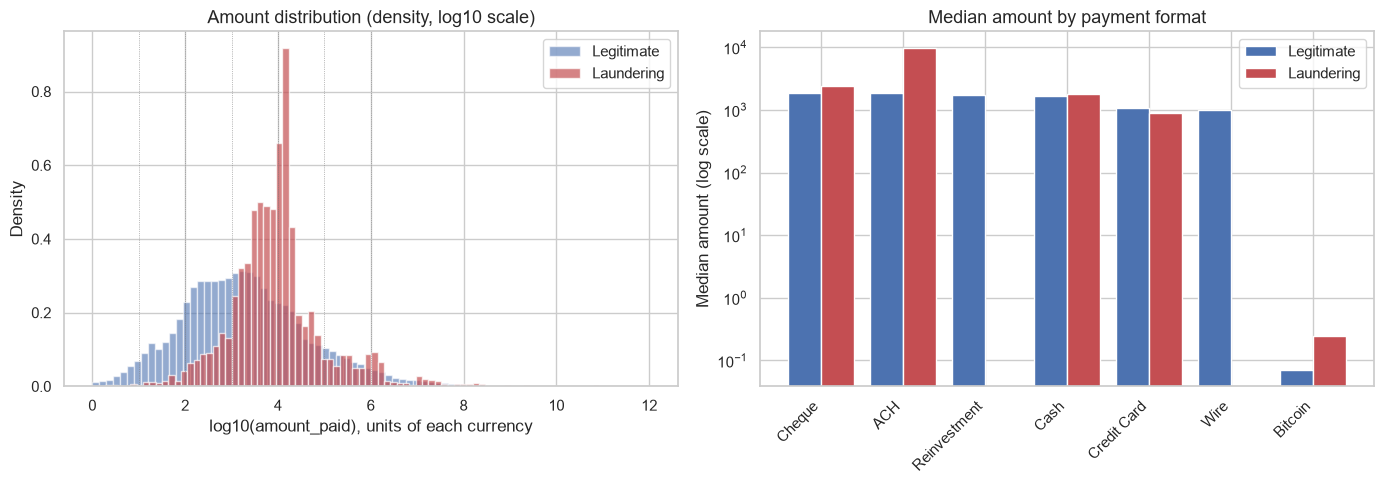

Saved: c:\Users\Priyam Srivastava\code\flowtrace\reports\figures\03_amount_distributions.png


In [16]:
# Amount distribution: legit vs laundering, log scale (because tails)
import numpy as np

paid_legit = df.filter(pl.col("is_laundering") == 0)["amount_paid"].to_numpy()
paid_laund = df.filter(pl.col("is_laundering") == 1)["amount_paid"].to_numpy()

# Clip to >= $1 for log scale; tiny amounts handled separately below
paid_legit_log = np.log10(paid_legit[paid_legit >= 1])
paid_laund_log = np.log10(paid_laund[paid_laund >= 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms, log10 of amount
axes[0].hist(paid_legit_log, bins=80, alpha=0.6, label="Legitimate", color="#4c72b0", density=True)
axes[0].hist(paid_laund_log, bins=80, alpha=0.7, label="Laundering", color="#c44e52", density=True)
axes[0].set_xlabel("log10(amount_paid), units of each currency")
axes[0].set_ylabel("Density")
axes[0].set_title("Amount distribution (density, log10 scale)")
axes[0].legend()
# Mark common decade boundaries for readability
for x in [1, 2, 3, 4, 5, 6]:
    axes[0].axvline(x, color="grey", linewidth=0.5, linestyle=":")

# Right: median amount by payment format, grouped by laundering label
median_by_format = (
    df.group_by(["payment_format", "is_laundering"])
    .agg(pl.col("amount_paid").median().alias("median_amount"))
    .sort("payment_format")
    .pivot(values="median_amount", index="payment_format", on="is_laundering")
    .rename({"0": "legit", "1": "laund"})
    .fill_null(0)
    .sort("legit", descending=True)
    .to_pandas()
)

x_pos = np.arange(len(median_by_format))
width = 0.4
axes[1].bar(x_pos - width/2, median_by_format["legit"], width, label="Legitimate", color="#4c72b0")
axes[1].bar(x_pos + width/2, median_by_format["laund"], width, label="Laundering", color="#c44e52")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(median_by_format["payment_format"], rotation=45, ha="right")
axes[1].set_ylabel("Median amount (log scale)")
axes[1].set_yscale("log")
axes[1].set_title("Median amount by payment format")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "03_amount_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '03_amount_distributions.png'}")